# Predicting Electric Vehicle Purchases: Exploratory Data Analysis (EDA)

Kaggle Playground Series S6E9 (`playground-series-s6e9`). Binary
classification: predict the probability that `Will_Buy_EV = "Yes"` for each
test `id`; scored by **ROC AUC** (verified via the Kaggle API, 2026-09-01 —
see `docs/1_instructions.md`).

This notebook is the executable source of truth for the EDA; durable
conclusions are written to `docs/2_eda_insights.md`. It runs both on Kaggle
(competition input path) and locally (repo `data/`, gitignored).

## Environment

In [1]:
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from scipy.stats import chi2_contingency, ks_2samp
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme(style="whitegrid")
PALETTE = "viridis"

print("python", platform.python_version())
print({m.__name__: m.__version__ for m in (np, pd, sklearn, scipy, matplotlib, sns)})

python 3.11.15
{'numpy': '2.4.6', 'pandas': '2.3.3', 'sklearn': '1.9.0', 'scipy': '1.17.1', 'matplotlib': '3.11.1', 'seaborn': '0.13.2'}


## 1. Config & Data Loading

Single configuration block (master standard §4). `DATA_DIR` auto-detects the
Kaggle competition mount vs. the local repo layout.

In [2]:
SEED = 42
TARGET = "Will_Buy_EV"
POSITIVE_CLASS = "Yes"
MI_SAMPLE_SIZE = 150_000     # stratified subsample for mutual information
ADV_N_SPLITS = 3             # adversarial-validation folds
ADV_PERM_HOLDOUT = 100_000   # permutation-importance holdout size

NUMERIC_FEATURES = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]
CATEGORICAL_FEATURES = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level",
]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def _find_data_dir() -> Path:
    """Locate the competition files on Kaggle or locally.

    Kaggle has mounted competition data at both
    /kaggle/input/competitions/<slug> and /kaggle/input/<slug> depending on
    the worker, so per master standard §12 the mount tree is walked rather
    than assumed when the known layouts miss.
    """
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e9"),
        Path("/kaggle/input/playground-series-s6e9"),
        Path("../data"),
        Path("data"),
    ]
    for cand in candidates:
        if (cand / "train.csv").exists():
            return cand
    mount = Path("/kaggle/input")
    if mount.exists():
        hits = sorted(mount.rglob("train.csv"))
        if hits:
            return hits[0].parent
    raise FileNotFoundError("train.csv not found in any known location")


DATA_DIR = _find_data_dir()
print(f"DATA_DIR = {DATA_DIR.resolve()}")

DATA_DIR = /Users/tuannm3812/Documents/GitHub/2. Kaggle/kaggle-s6e9-predicting-electric-vehicle-purchases/data


In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

assert train.shape == (668_665, 15), train.shape
assert test.shape == (286_571, 14), test.shape
assert list(sample_submission.columns) == ["id", TARGET]
assert sorted(ALL_FEATURES) == sorted(
    c for c in train.columns if c not in ("id", TARGET)
)
assert train[ALL_FEATURES].isna().sum().sum() == 0
assert test[ALL_FEATURES].isna().sum().sum() == 0

y = (train[TARGET] == POSITIVE_CLASS).astype(int)
train.dtypes.to_frame("dtype")

,dtype
id,int64
Age,int64
Annual_Income_USD,float64
Daily_Commute_km,float64
Number_of_Cars_Owned,int64
Charging_Stations_Near_Home,int64
Charging_Stations_Near_Work,int64
Environmental_Concern_Level,float64
Gender,object
City_Type,object


**Insight:** schema matches `docs/1_instructions.md` exactly — 668,665 × 15
train, 286,571 × 14 test, 13 features (7 numeric, 6 categorical), and the
asserts confirm **zero missing values in either split**. Unlike S6E8, there
is no missingness workstream at all in this competition.

## 2. Target Framing

In [4]:
target_counts = train[TARGET].value_counts()
prevalence = float(y.mean())
sub_constant = float(sample_submission[TARGET].iloc[0])
print(target_counts.to_string())
print(f"positive rate: {prevalence:.6f}")
print(
    f"sample_submission constant: {sub_constant:.6f} "
    f"(all rows equal: {(sample_submission[TARGET] == sub_constant).all()})"
)

Will_Buy_EV
No     551886
Yes    116779
positive rate: 0.174645
sample_submission constant: 0.174645 (all rows equal: True)


**Insight:** positive rate is `116,779 / 668,665 = 0.174645`. The
`sample_submission.csv` constant is exactly that value in every row —
confirming the expected output is `P(Will_Buy_EV = "Yes")` as a probability,
and that the organizers' reference baseline is the train prevalence.

## 3. Numeric Feature Signal: Distributions, Univariate AUC, Cohen's d

Raw class-mean gaps are not comparable across differently-scaled features, so
the ranking below uses two scale-free diagnostics: orientation-free univariate
AUC (rank-based, matches the competition metric's invariances) and Cohen's
*d* (standardized mean difference).

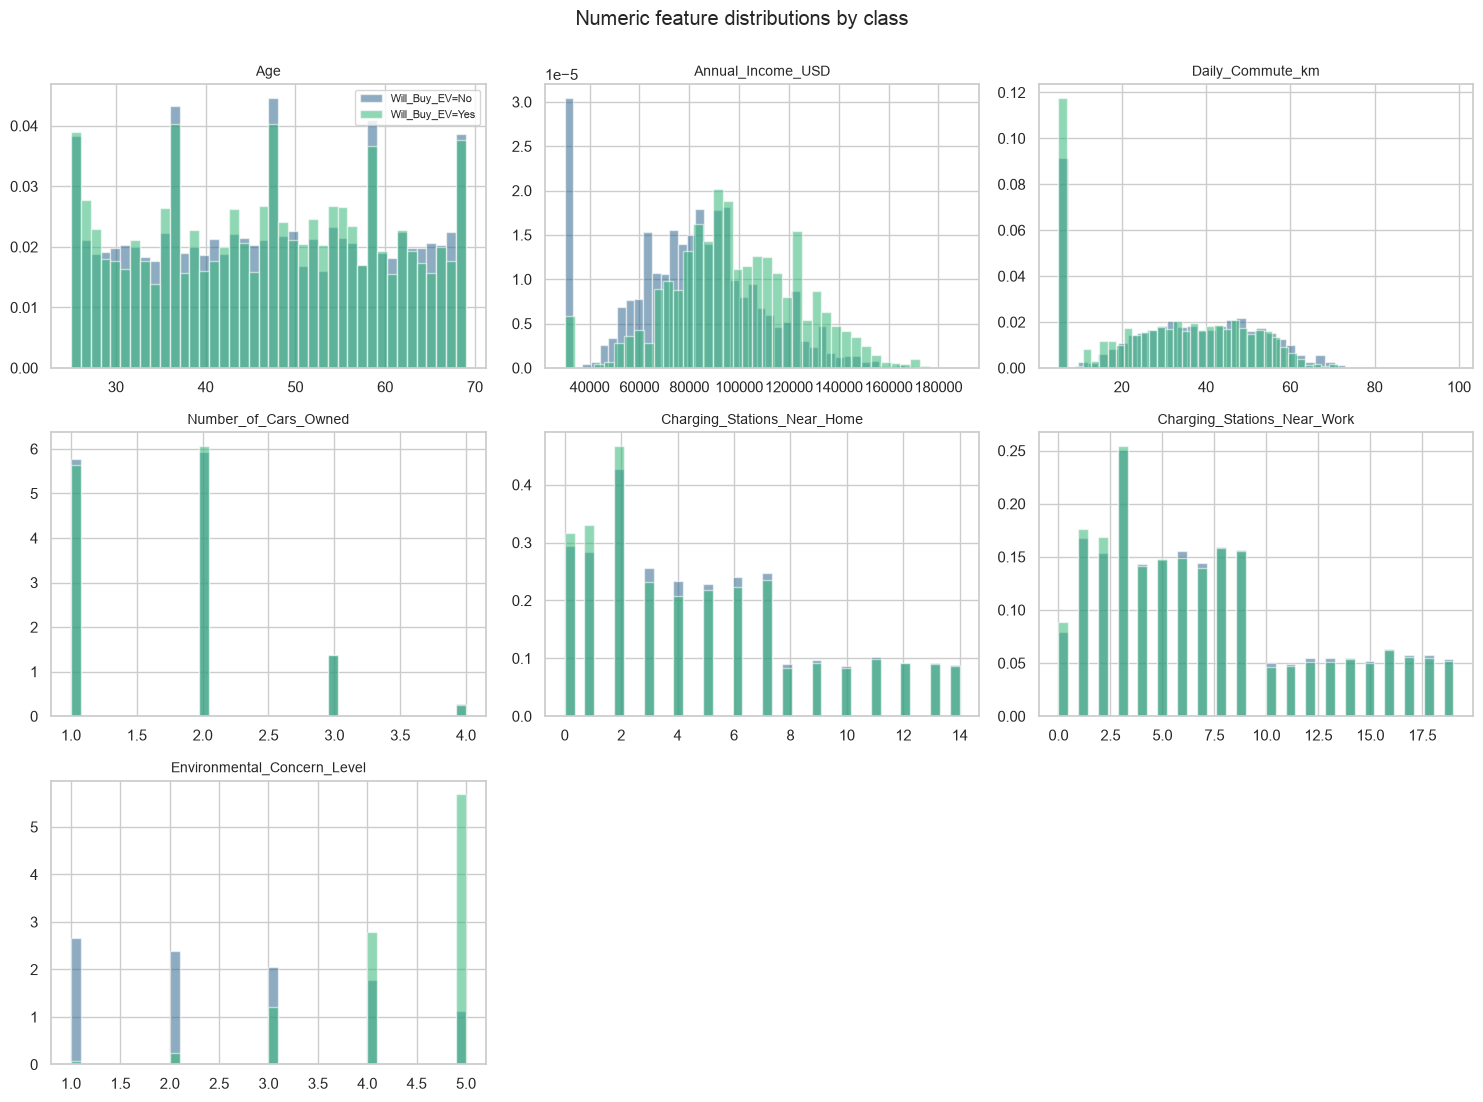

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
class_colors = sns.color_palette(PALETTE, 2)
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    for label, color in zip((0, 1), class_colors):
        ax.hist(
            train.loc[y == label, col],
            bins=40,
            density=True,
            alpha=0.55,
            color=color,
            label=f"{TARGET}={'Yes' if label else 'No'}",
        )
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8)
fig.suptitle("Numeric feature distributions by class", y=1.0)
fig.tight_layout()
plt.show()

In [6]:
def univariate_auc(values: pd.Series, labels: pd.Series) -> float:
    """Orientation-free AUC of a single raw feature.

    Args:
        values: Feature values.
        labels: Binary 0/1 target.

    Returns:
        max(AUC, 1 - AUC), so direction does not matter.
    """
    auc = roc_auc_score(labels, values)
    return float(max(auc, 1.0 - auc))


def cohens_d(values: pd.Series, labels: pd.Series) -> float:
    """Standardized mean difference between classes (pooled SD)."""
    a, b = values[labels == 1], values[labels == 0]
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / pooled)


numeric_signal = pd.DataFrame({
    "univariate_auc": {c: univariate_auc(train[c], y) for c in NUMERIC_FEATURES},
    "cohens_d": {c: cohens_d(train[c], y) for c in NUMERIC_FEATURES},
}).sort_values("univariate_auc", ascending=False).round(4)
numeric_signal

,univariate_auc,cohens_d
Environmental_Concern_Level,0.8435,1.5618
Annual_Income_USD,0.6704,0.6242
Daily_Commute_km,0.5338,-0.1223
Charging_Stations_Near_Home,0.5159,-0.0429
Charging_Stations_Near_Work,0.5106,-0.0322
Age,0.5055,-0.0197
Number_of_Cars_Owned,0.5039,0.0103


**Insight:** the numeric signal is extremely top-heavy.
`Environmental_Concern_Level` towers over everything (univariate AUC
**0.8435**, Cohen's *d* 1.56); `Annual_Income_USD` is a clear second (0.6704,
*d* 0.62). Every other numeric is near-noise marginally (AUC ≤ 0.534):
commute distance, both charging-station counts, age, and cars owned have
essentially no univariate signal, so any value they add must come through
interactions — a question for the models, not for more univariate EDA.

## 4. Categorical Features: Target Rate by Level

Per-level positive rate with its standard error — `Range_Anxiety_Level=High`
has only ~2.2k rows (0.33%), so its rate estimate deserves an explicit SE.

In [7]:
cat_rows = []
for col in CATEGORICAL_FEATURES:
    rate = y.groupby(train[col]).mean()
    n = train[col].value_counts()
    for level in rate.index:
        p, m = float(rate[level]), int(n[level])
        cat_rows.append({
            "feature": col,
            "level": level,
            "n": m,
            "positive_rate": round(p, 4),
            "se": round(float(np.sqrt(p * (1 - p) / m)), 4),
        })
cat_table = pd.DataFrame(cat_rows)
print(cat_table.to_string(index=False))

               feature     level      n  positive_rate     se
                Gender    Female 295427         0.1776 0.0007
                Gender      Male 367954         0.1723 0.0006
                Gender     Other   5284         0.1737 0.0052
             City_Type     Rural 123983         0.1934 0.0011
             City_Type  Suburban 255377         0.1809 0.0008
             City_Type     Urban 289305         0.1611 0.0007
      Current_Car_Type Hatchback  79438         0.1743 0.0013
      Current_Car_Type       SUV 246545         0.1810 0.0008
      Current_Car_Type     Sedan 303459         0.1720 0.0007
      Current_Car_Type     Truck  39223         0.1564 0.0018
Home_Charging_Possible        No 205988         0.1271 0.0007
Home_Charging_Possible       Yes 462677         0.1958 0.0006
     Subsidy_Available        No 248756         0.0058 0.0002
     Subsidy_Available       Yes 419909         0.2747 0.0007
   Range_Anxiety_Level      High   2194         0.0014 0.0008
   Range

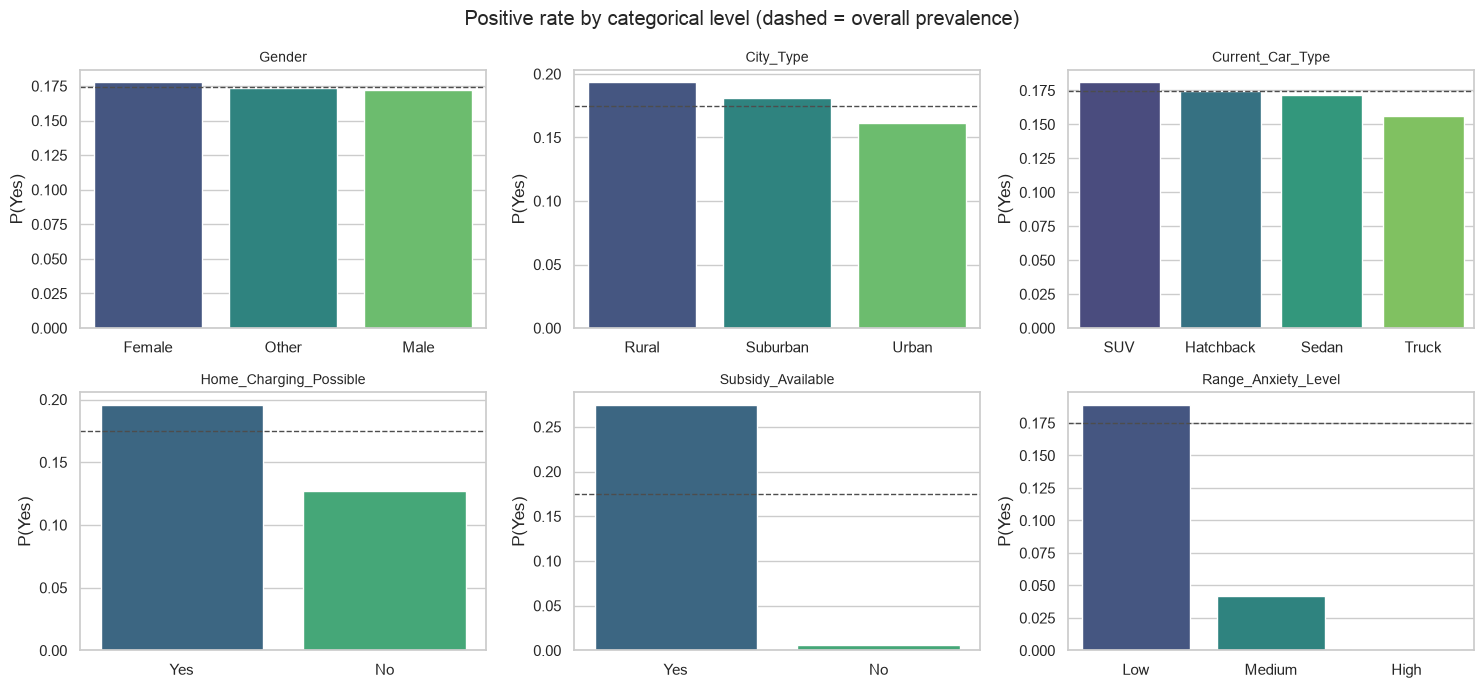

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    rates = y.groupby(train[col]).mean().sort_values(ascending=False)
    sns.barplot(
        x=rates.index.tolist(),
        y=rates.values,
        hue=rates.index.tolist(),
        palette=PALETTE,
        legend=False,
        ax=ax,
    )
    ax.axhline(prevalence, color="0.3", ls="--", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("P(Yes)")
    ax.set_xlabel("")
fig.suptitle("Positive rate by categorical level (dashed = overall prevalence)")
fig.tight_layout()
plt.show()

**Insight:** `Subsidy_Available` is close to a hard gate: **0.58%** positive
without a subsidy vs. **27.47%** with (univariate AUC 0.7179 — remarkable for
a binary feature). `Range_Anxiety_Level` is strongly monotone-decreasing
(18.90% → 4.17% → 0.14%); its `High` level is rare (n = 2,194, 0.33%) but the
rate estimate is still precise (SE ≈ 0.08 points). `Home_Charging_Possible`
shifts the rate 12.71% → 19.58%. `Gender`, `City_Type`, and
`Current_Car_Type` carry small spreads (≤ 3.2 points).

## 5. Ordinal Structure Check

`Environmental_Concern_Level` (discrete 1–5, stored as float) and
`Range_Anxiety_Level` (Low/Medium/High) look ordinal. If the target rate is
monotone in the level, ordinal encoding is a candidate; if not (S6E8's
`stress_level` was non-monotonic), treat-as-categorical stays the default and
ordinal encoding becomes an OOF experiment, not an assumption.

In [9]:
env_rate = y.groupby(train["Environmental_Concern_Level"]).mean()
env_n = train["Environmental_Concern_Level"].value_counts().sort_index()
print("Environmental_Concern_Level:")
print(pd.DataFrame({"n": env_n, "positive_rate": env_rate.round(4)}).to_string())

anx_order = ["Low", "Medium", "High"]
anx_rate = y.groupby(train["Range_Anxiety_Level"]).mean().reindex(anx_order)
anx_n = train["Range_Anxiety_Level"].value_counts().reindex(anx_order)
print("\nRange_Anxiety_Level:")
print(pd.DataFrame({"n": anx_n, "positive_rate": anx_rate.round(4)}).to_string())

Environmental_Concern_Level:
                                  n  positive_rate
Environmental_Concern_Level                       
1.0                          147476         0.0057
2.0                          135133         0.0214
3.0                          127351         0.1109
4.0                          130469         0.2488
5.0                          128236         0.5183

Range_Anxiety_Level:
                          n  positive_rate
Range_Anxiety_Level                       
Low                  603972         0.1890
Medium                62499         0.0417
High                   2194         0.0014


**Insight:** both ordinal candidates are **strictly monotone** in target
rate: `Environmental_Concern_Level` runs 0.57% → 2.14% → 11.09% → 24.88% →
51.83% across levels 1–5, and `Range_Anxiety_Level` runs 18.90% → 4.17% →
0.14% across Low/Medium/High. `Environmental_Concern_Level` already arrives
numeric — keep it numeric. For `Range_Anxiety_Level`, ordinal encoding
(Low=0 < Medium=1 < High=2) is the justified default for GBDTs, with
treat-as-categorical as a cheap A/B, not the other way round (the reverse of
S6E8's non-monotonic `stress_level`).

## 6. Conditional Target Rates: Charging Infrastructure

Domain-plausible interaction checks: does the effect of nearby public
charging depend on whether home charging is possible, and do home charging
and subsidy availability combine additively or not?

P(Yes) by Home_Charging_Possible x Subsidy_Available:
Subsidy_Available           No    Yes
Home_Charging_Possible               
No                      0.0040  0.206
Yes                     0.0066  0.304


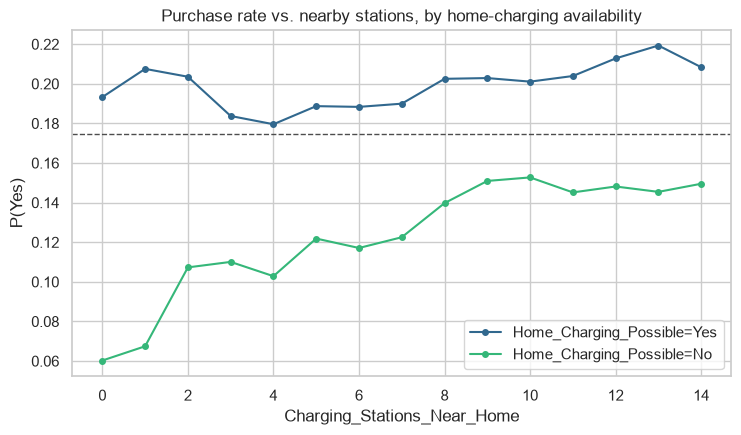

In [10]:
pivot = (
    y.groupby([train["Home_Charging_Possible"], train["Subsidy_Available"]])
    .mean()
    .unstack()
    .round(4)
)
print("P(Yes) by Home_Charging_Possible x Subsidy_Available:")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for hc, color in zip(("Yes", "No"), sns.color_palette(PALETTE, 2)):
    mask = train["Home_Charging_Possible"] == hc
    rates = y[mask].groupby(train.loc[mask, "Charging_Stations_Near_Home"]).mean()
    ax.plot(
        rates.index, rates.values, marker="o", ms=4,
        color=color, label=f"Home_Charging_Possible={hc}",
    )
ax.axhline(prevalence, color="0.3", ls="--", lw=1)
ax.set_xlabel("Charging_Stations_Near_Home")
ax.set_ylabel("P(Yes)")
ax.set_title("Purchase rate vs. nearby stations, by home-charging availability")
ax.legend()
plt.show()

**Insight:** the subsidy gates everything else. Without a subsidy,
P(Yes) is 0.40% (no home charging) vs. 0.66% (home charging possible) — home
charging barely matters. With a subsidy it is 20.6% vs. **30.4%** — a
10-point effect. That is a textbook interaction: tree ensembles find it
natively; only a linear baseline would need the explicit product. The
charging-station counts stay near-flat in both panels, consistent with their
≈0.51 univariate AUC in §3.

## 7. Feature Signal Ranking: Pearson, Univariate AUC, Mutual Information

Three complementary, deliberately different diagnostics — none is treated as
authoritative alone. Pearson sees linear signal on numerics; univariate AUC
sees monotone signal; mutual information (on a stratified subsample) sees
arbitrary dependence. Categorical univariate AUC uses per-level target-rate
ordering computed on the full train set — fine as an *EDA diagnostic*, but
that construction is leaky if reused as a model feature outside CV folds
(master standard §5).

In [11]:
pearson = train[NUMERIC_FEATURES].corrwith(y).abs()

cat_auc = {}
for col in CATEGORICAL_FEATURES:
    level_rate = y.groupby(train[col]).mean()
    cat_auc[col] = univariate_auc(train[col].map(level_rate), y)
all_auc = {c: univariate_auc(train[c], y) for c in NUMERIC_FEATURES} | cat_auc

mi_idx, _ = train_test_split(
    np.arange(len(train)),
    train_size=MI_SAMPLE_SIZE,
    stratify=y,
    random_state=SEED,
)
X_mi = train.iloc[mi_idx][ALL_FEATURES].copy()
X_mi[CATEGORICAL_FEATURES] = OrdinalEncoder().fit_transform(
    X_mi[CATEGORICAL_FEATURES]
)
DISCRETE = set(CATEGORICAL_FEATURES) | {
    "Age",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
}
mi_values = mutual_info_classif(
    X_mi,
    y.iloc[mi_idx],
    discrete_features=np.array([c in DISCRETE for c in ALL_FEATURES]),
    random_state=SEED,
)

ranking = pd.DataFrame({
    "pearson_abs": pearson,
    "univariate_auc": pd.Series(all_auc),
    "mutual_info": pd.Series(mi_values, index=ALL_FEATURES),
}).sort_values("univariate_auc", ascending=False).round(4)
ranking

,pearson_abs,univariate_auc,mutual_info
Environmental_Concern_Level,0.4641,0.8435,0.1266
Subsidy_Available,NaN,0.7179,0.0812
Annual_Income_USD,0.2257,0.6704,0.0516
Home_Charging_Possible,NaN,0.5508,0.0035
Range_Anxiety_Level,NaN,0.5451,0.0091
Daily_Commute_km,0.0459,0.5338,0.0043
City_Type,NaN,0.5234,0.0004
Charging_Stations_Near_Home,0.0164,0.5159,0.0006
Charging_Stations_Near_Work,0.0122,0.5106,0.0001
Current_Car_Type,NaN,0.5104,0.0002


**Insight:** all three diagnostics agree on the same top tier —
`Environmental_Concern_Level`, `Subsidy_Available`, `Annual_Income_USD` —
followed by `Range_Anxiety_Level` and `Home_Charging_Possible`. Mutual
information finds **no hidden nonlinear heavyweight** among the weak
features (everything outside the top five has MI ≤ 0.004): the S6E8
situation, where MI rescued two Pearson-invisible features, does not recur
here. Caveats: MI is computed on a 150k stratified subsample, and the
categorical univariate AUC uses full-train level rates (EDA diagnostic only —
leaky if reused as a model feature outside folds).

## 8. Duplicate Rows

Three counts, computed separately: train-internal, test-internal, and
cross-set (test rows whose full feature tuple also appears in train).

In [12]:
train_feat = train[ALL_FEATURES]
test_feat = test[ALL_FEATURES]
train_internal = int(train_feat.duplicated().sum())
test_internal = int(test_feat.duplicated().sum())
cross = test_feat.merge(
    train_feat.drop_duplicates(), how="inner", on=ALL_FEATURES
).shape[0]
print(f"train-internal duplicate feature rows: {train_internal}")
print(f"test-internal duplicate feature rows:  {test_internal}")
print(f"test rows whose feature tuple appears in train: {cross}")

train-internal duplicate feature rows: 0
test-internal duplicate feature rows:  0
test rows whose feature tuple appears in train: 0


**Insight:** all three counts are exactly **0** — no duplicated feature
tuples inside train, inside test, or across the two. There is no
duplication-based leakage channel and no train-membership signal to exploit;
row-level modeling assumptions are clean.

## 9. Train/Test Distribution Checks

With n in the hundreds of thousands, p-values are uninformative — trivially
small distributional differences reject. Read the *effect sizes*: the KS
statistic and the max absolute proportion delta.

### 9.1 Numeric features (Kolmogorov–Smirnov)

In [13]:
drift_rows = []
for col in NUMERIC_FEATURES:
    stat, p = ks_2samp(train[col], test[col])
    drift_rows.append({
        "feature": col,
        "ks_stat": round(float(stat), 5),
        "p_value": float(p),
        "train_range": (float(train[col].min()), float(train[col].max())),
        "test_range": (float(test[col].min()), float(test[col].max())),
    })
pd.DataFrame(drift_rows)

,feature,ks_stat,p_value,train_range,test_range
0,Age,0.00229,0.241771,"(25.0, 69.0)","(25.0, 69.0)"
1,Annual_Income_USD,0.00164,0.653217,"(30000.0, 188549.0)","(30000.0, 186936.0)"
2,Daily_Commute_km,0.00107,0.976165,"(5.0, 98.7)","(5.0, 103.9)"
3,Number_of_Cars_Owned,0.00166,0.637171,"(1.0, 4.0)","(1.0, 4.0)"
4,Charging_Stations_Near_Home,0.00158,0.698836,"(0.0, 14.0)","(0.0, 14.0)"
5,Charging_Stations_Near_Work,0.00300,0.053355,"(0.0, 19.0)","(0.0, 19.0)"
6,Environmental_Concern_Level,0.00127,0.901569,"(1.0, 5.0)","(1.0, 5.0)"


### 9.2 Categorical features (proportion deltas + chi-square)

In [14]:
for col in CATEGORICAL_FEATURES:
    tr = train[col].value_counts(normalize=True)
    te = test[col].value_counts(normalize=True)
    delta = float((tr - te).abs().max())
    counts = pd.concat(
        [train[col].value_counts(), test[col].value_counts()],
        axis=1,
        keys=["train", "test"],
    ).fillna(0)
    chi2, p, _, _ = chi2_contingency(counts.T.values)
    print(f"{col:28s} max |d proportion| = {delta:.5f}   chi2 p = {p:.3g}")

Gender                       max |d proportion| = 0.00020   chi2 p = 0.972
City_Type                    max |d proportion| = 0.00135   chi2 p = 0.472
Current_Car_Type             max |d proportion| = 0.00075   chi2 p = 0.552


Home_Charging_Possible       max |d proportion| = 0.00066   chi2 p = 0.522
Subsidy_Available            max |d proportion| = 0.00145   chi2 p = 0.178
Range_Anxiety_Level          max |d proportion| = 0.00171   chi2 p = 0.00198


**Insight:** train and test are statistically indistinguishable
univariately. KS statistics are ≤ 0.003 on every numeric (most p-values are
non-significant *even at n ≈ 10⁶*), and categorical proportion deltas are
≤ 0.17 points (`Range_Anxiety_Level`'s chi-square p = 0.002 reflects the
enormous n, not a material shift). The only range difference:
`Daily_Commute_km` reaches 103.9 in test vs. 98.7 in train — a 5 km
extension affecting a handful of rows; tree models extrapolate flat there,
so no action is needed.

## 10. Adversarial Validation

Multivariate diagnostic: a 3-fold out-of-fold `HistGradientBoostingClassifier`
trained to distinguish train rows from test rows (native categorical
handling, no encoding choices to confound the result). OOF AUC ≈ 0.5 means
train and test are effectively indistinguishable; a materially higher AUC
would be background context for interpreting any CV-vs-leaderboard gap.

In [15]:
adv_X = pd.concat(
    [train[ALL_FEATURES], test[ALL_FEATURES]], ignore_index=True
)
for col in CATEGORICAL_FEATURES:
    adv_X[col] = adv_X[col].astype("category")
adv_y = np.r_[np.zeros(len(train), dtype=int), np.ones(len(test), dtype=int)]

adv_model = HistGradientBoostingClassifier(
    random_state=SEED, categorical_features="from_dtype"
)
adv_cv = StratifiedKFold(
    n_splits=ADV_N_SPLITS, shuffle=True, random_state=SEED
)
adv_oof = cross_val_predict(
    adv_model, adv_X, adv_y, cv=adv_cv, method="predict_proba"
)[:, 1]
adv_auc = float(roc_auc_score(adv_y, adv_oof))
print(f"Adversarial validation OOF AUC ({ADV_N_SPLITS}-fold): {adv_auc:.4f}")

Adversarial validation OOF AUC (3-fold): 0.4992


In [16]:
if adv_auc >= 0.55:
    X_fit, X_hold, y_fit, y_hold = train_test_split(
        adv_X,
        adv_y,
        test_size=ADV_PERM_HOLDOUT,
        stratify=adv_y,
        random_state=SEED,
    )
    drill = HistGradientBoostingClassifier(
        random_state=SEED, categorical_features="from_dtype"
    ).fit(X_fit, y_fit)
    imp = permutation_importance(
        drill, X_hold, y_hold, scoring="roc_auc", n_repeats=5,
        random_state=SEED,
    )
    print("Permutation importance (holdout AUC drop per feature):")
    print(
        pd.Series(imp.importances_mean, index=ALL_FEATURES)
        .sort_values(ascending=False)
        .round(5)
        .to_string()
    )
else:
    print(
        f"OOF AUC {adv_auc:.4f} < 0.55 - train and test are effectively "
        "indistinguishable; permutation drill-down skipped."
    )

OOF AUC 0.4992 < 0.55 - train and test are effectively indistinguishable; permutation drill-down skipped.


**Insight:** OOF AUC **0.4992** — a classifier given every feature cannot
tell train from test at all, so the permutation drill-down was skipped by
the predeclared 0.55 rule. Combined with §9, the practical conclusion:
**local CV should track the leaderboard closely**, and any future CV-vs-LB
gap should be blamed on modeling choices (overfitting, leakage), not on
distribution shift.

## 11. What This EDA Established

Findings only — modeling plans live in `docs/`, since this notebook is
published.

- **Target:** `Will_Buy_EV`, 17.46% positive; `sample_submission.csv`'s
  constant is exactly that prevalence, so the expected output is a
  probability (§2).
- **Signal is top-heavy:** `Environmental_Concern_Level` (univariate AUC
  0.8435), `Subsidy_Available` (0.7179) and `Annual_Income_USD` (0.6704)
  carry nearly all marginal signal; the remaining ten features sit at
  0.504–0.551, and mutual information finds no hidden nonlinear
  heavyweight among them (§3, §7).
- **Both ordinal candidates are strictly monotone** in target rate —
  `Environmental_Concern_Level` 0.57% → 51.83% across levels 1–5, and
  `Range_Anxiety_Level` 18.90% → 4.17% → 0.14% (§5).
- **One large interaction:** subsidy availability gates everything else.
  Without a subsidy, purchase probability is under 0.7% regardless of home
  charging; with one, home charging adds ~10 points (§6).
- **The data is clean:** no missing values, and zero duplicate feature
  rows within train, within test, or across the two (§1, §8).
- **No train/test drift:** KS ≤ 0.003 on every numeric, categorical
  proportion deltas ≤ 0.17 points, and adversarial validation OOF AUC
  **0.4992** — train and test are effectively indistinguishable, so local
  CV should track the leaderboard (§9, §10).
- **Runtime:** this full EDA, including a 3-fold adversarial fit over all
  955,236 combined rows, runs in ~21 s — the data is computationally
  light despite the large row count.

## Reproducibility Snapshot

In [17]:
snapshot = {
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "seed": SEED,
    "data_dir": str(DATA_DIR),
    "train_shape": list(train.shape),
    "test_shape": list(test.shape),
    "mi_sample_size": MI_SAMPLE_SIZE,
    "adv_n_splits": ADV_N_SPLITS,
    "versions": {
        m.__name__: m.__version__
        for m in (np, pd, sklearn, scipy, matplotlib, sns)
    },
}
print(json.dumps(snapshot, indent=2))

{
  "generated_utc": "2026-09-01T10:00:09+00:00",
  "seed": 42,
  "data_dir": "../data",
  "train_shape": [
    668665,
    15
  ],
  "test_shape": [
    286571,
    14
  ],
  "mi_sample_size": 150000,
  "adv_n_splits": 3,
  "versions": {
    "numpy": "2.4.6",
    "pandas": "2.3.3",
    "sklearn": "1.9.0",
    "scipy": "1.17.1",
    "matplotlib": "3.11.1",
    "seaborn": "0.13.2"
  }
}
